In [65]:
from data_cleanup import functions

import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [66]:
#angepasst auf finale datei
seq_regions = ['SEQ_H1', 'SEQ_H2', 'SEQ_L1', 'SEQ_L2', 'SEQ_L3']
cf_regions = ['CF_H1', 'CF_H2', 'CF_L1', 'CF_L2', 'CF_L3']
df = (
    pd.read_csv("data/ab_ag_scalop.tsv", sep="\t")
    .dropna(subset=seq_regions)
    .dropna(subset=cf_regions)
    .drop_duplicates(subset=seq_regions) 
)
antigen_labels = df["antigen_name"].tolist()
antigen_counts = df["antigen_name"].value_counts() # Tabelle aus antigen_names und ihren Häufigkeiten in der Spalte antigen_name
df = df[df["antigen_name"].isin(antigen_counts[antigen_counts >= 5].index)] # Behält nur Zeilen, deren antigen_name mindestens 5-mal vorkommt

In [67]:
# Erstellen eines Dictionaries, in dem die Feature-Space DataFrames gespeichert werden, sodass nur Embeddings verwendet werden, aus den gefilterten Daten (ab_ag_scalop.tsv)
feature_spaces = {}

# Extrahiere alle relevanten Spalten aus dem Master-DataFrame `df`und wandle sie in eine Liste von Zeilen um. 
df_rows = df[["pdb", "Hchain", "Lchain", "model", "antigen_name", "antigen_species", "SEQ_H1", "SEQ_H2", "SEQ_L1", "SEQ_L2", "SEQ_L3"]].values.tolist()

# Für jede gewünschte CDR-Region (z.B. 'SEQ_H1', 'SEQ_L2' usw.)
for seq_region in seq_regions:
    # Leere Liste zum Sammeln der Zeilen dieses Feature-Spaces
    fs_rows = []

    # Iteriere über jede Zeile aus df_rows
    for df_row in df_rows:
        pdb            = df_row[0]  # PDB-Identifikator
        hchain         = df_row[1]  # Heavy-Chain-Kette
        lchain         = df_row[2]  # Light-Chain-Kette
        model          = df_row[3]  # Modellbezeichnung
        antigen_name   = df_row[4]  # Name des Antigens
        antigen_species= df_row[5]  # Spezies des Antigens

        # Wähle die korrekte Sequenz-Spalte abhängig von seq_region
        match seq_region:
            case "SEQ_H1":
                region = df_row[6]
            case "SEQ_H2":
                region = df_row[7]
            case "SEQ_L1":
                region = df_row[8]
            case "SEQ_L2":
                region = df_row[9]
            case "SEQ_L3":
                region = df_row[10]

        # Bestimme, ob es sich um die Heavy- oder Light-Chain handelt seq_region[4] nimmt das Zeichen nach dem Unterstrich (H oder L)
        if seq_region[4] == "H":
            chain_id = hchain
        else:
            chain_id = lchain

        # Lade das Embedding-Array für diesen PDB-Eintrag und diese Region Dateiname z.B.: "data/embeddings/1ABC_A_SEQ_H1_chothia.npy"
        embedding_as_arr = np.load(f"data/embeddings/{pdb}/{pdb}_{chain_id}_{seq_region[4]}_{seq_region}_chothia.npy"
        )

        # Reduziere die Embedding-Dimension auf 1 mittels PCA und forme den Vektor zu einer flachen Liste um
        embedding_as_vec = PCA(n_components=1) .fit_transform(embedding_as_arr.T) .flatten()

        # Erstelle eine Datenzeile mit allen Meta-Infos + Embedding-Vektor
      
        fs_row = [pdb, hchain, lchain, model, antigen_name, antigen_species, region] + embedding_as_vec.tolist()

        # Füge die Zeile der Liste hinzu
        fs_rows.append(fs_row)

    # Wandle die gesammelten Zeilen in einen pandas DataFrame um
    # Spaltennamen: fixed Meta-Spalten + dynamisch erzeugte "embedding_dimension i"
    feature_space = pd.DataFrame(fs_rows,columns=["pdb", "Hchain", "Lchain", "model", "antigen_name", "antigen_species", seq_region] + [f"embedding_dimension {e}" for e in range(embedding_as_vec.shape[0])])
    # Speichere den DataFrame im Dictionary unter dem Key der aktuellen Region
    feature_spaces[seq_region] = feature_space



→ SEQ_H1: 712 Sequenzen zum Clustern
   MaxDist=13.359, Cut@50%=6.679


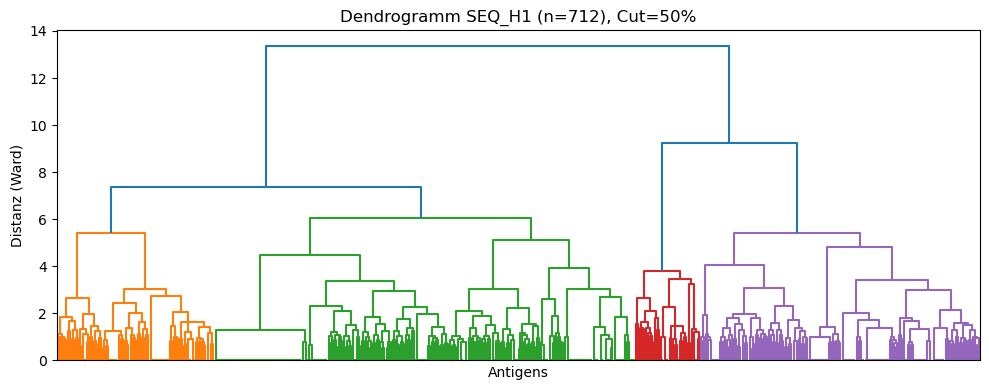


→ SEQ_H2: 712 Sequenzen zum Clustern
   MaxDist=10.447, Cut@50%=5.224


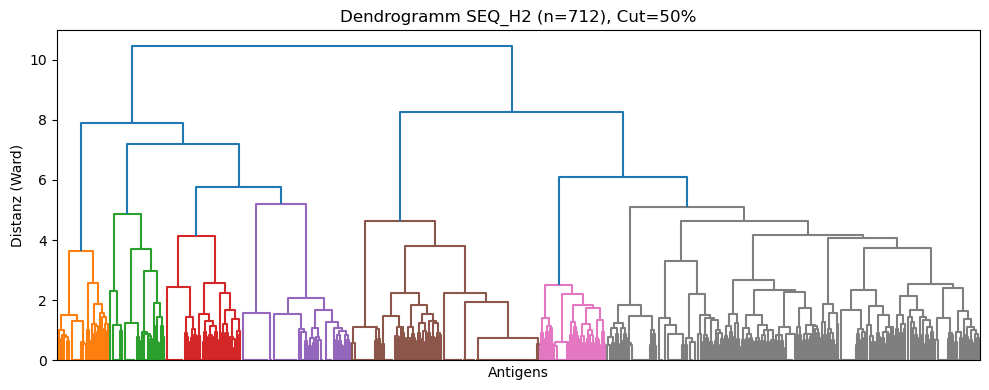


→ SEQ_L1: 712 Sequenzen zum Clustern
   MaxDist=20.233, Cut@50%=10.116


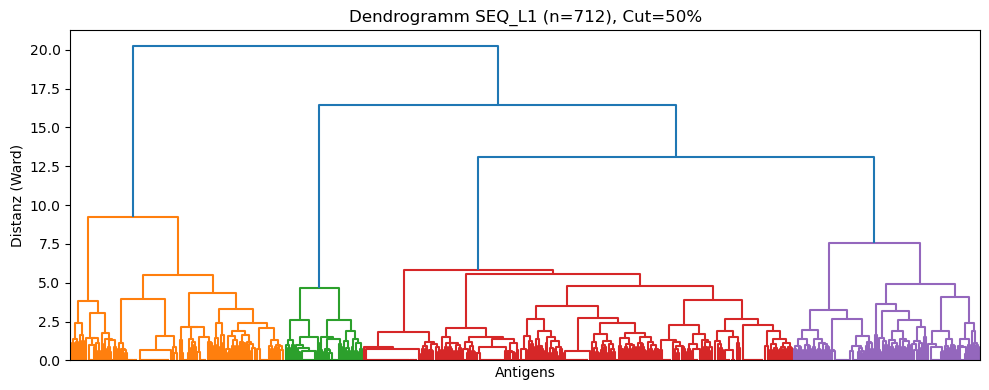


→ SEQ_L2: 712 Sequenzen zum Clustern
   MaxDist=12.782, Cut@50%=6.391


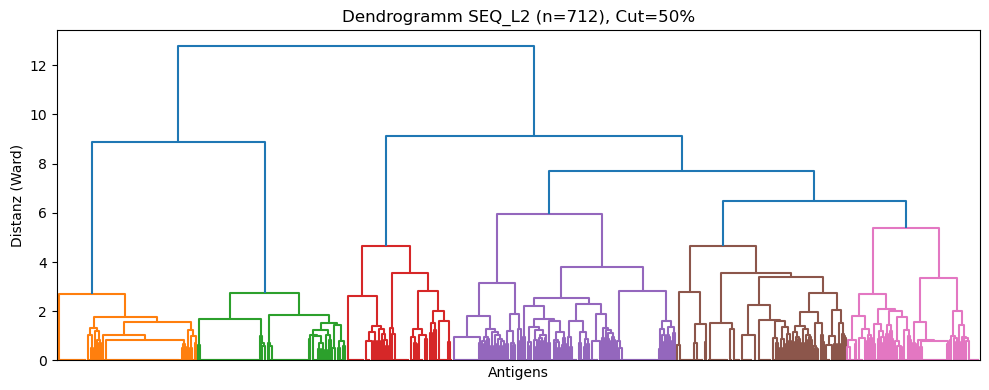


→ SEQ_L3: 712 Sequenzen zum Clustern
   MaxDist=22.485, Cut@50%=11.242


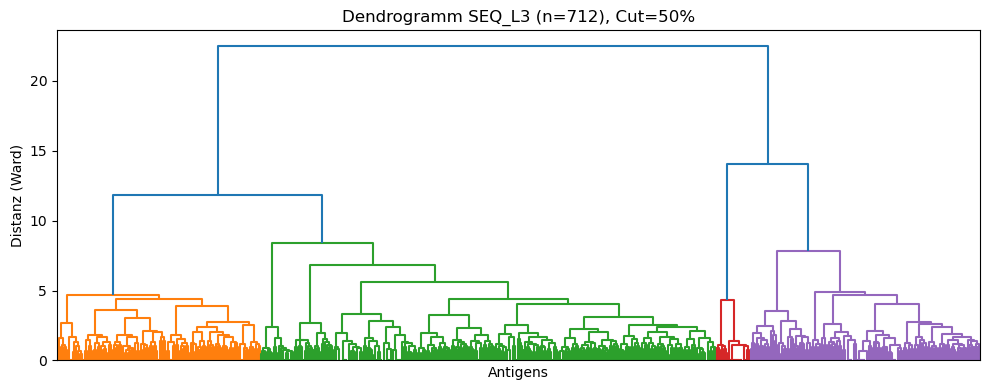

In [68]:
# Hierarchical Clustering aus bestehenden Feature-Spaces ohne Vorsortierung 
# Jeder DataFrame enthält Spalten:
# ['pdb', 'Hchain', 'Lchain', 'sequence','embedding_dimension 0', ..., 'embedding_dimension N']

threshold_ratio = 0.5  # 50% der maximalen Merge-Distanz als Cut

# Ausgabe-Ordner für neu erstellte TSVs Dateien die die Informationen für Cluster Zugehörigkeiten enthalten
outdir = "data/cdr_cluster_ESMC_tsvs"
# Sicher stellen, dass der Ordner existiert
os.makedirs(outdir, exist_ok=True)

for region in seq_regions:
    # hole DataFrame mit Embeddings und weiteren Infos für diese Region
    fs = feature_spaces.get(region)
    # wenn kein DataFrame gefunden oder leer, nächste Region
    if fs is None or fs.empty:
        continue 
    # Embedding-Spalten finden
    emb_cols = [c for c in fs.columns if c.startswith('embedding_dimension')]
    # falls keine Embedding-Spalten vorhanden sind, Region überspringen
    if not emb_cols:
        continue

    # Feature‐Matrix und Labels
    X = fs[emb_cols].values
    #unique namen erstellen für die einträge aus pdb, Hchain und Lchain
    labels = (
        fs['pdb'].astype(str)
        + '_' + fs['Hchain'].fillna('')
        + fs['Lchain'].fillna('')
    )
    #anzahl der gefundenen einträge (Zeilen)
    n = X.shape[0]
    print(f"\n→ {region}: {n} Sequenzen zum Clustern")
    #wenn weniger als 2 Einträge, überspringen, weil kein clustering möglich
    if n < 2:
        continue

    # Clustering per Ward‐Linkage (hierarchisches Clustering)
    Z = linkage(X, method='ward', metric='euclidean') #erstellen dendogramm Baum
    max_dist = Z[-1,2] #größte Distanz im letzten Merge-Schritt
    cut = threshold_ratio * max_dist # Schwelle berechnen für cutoff
    print(f"   MaxDist={max_dist:.3f}, Cut@{threshold_ratio*100:.0f}%={cut:.3f}")

    # Cluster‐Labels ermitteln
    clusters = fcluster(Z, t=cut, criterion="distance") # Array von Cluster-IDs
    fs['cluster'] = clusters  # Cluster als neue Spalte im DataFrame

    # Alles als TSV speichern, inklusive aller Spalten + cluster
    out_path = os.path.join(outdir, f"clusters_{region}.tsv")
    with open(out_path, "w", newline="") as f:
        writer = csv.writer(f, delimiter="\t")
        # Header
        writer.writerow(list(fs.columns))
        # Zeilen schreiben
        writer.writerows(fs.values)
    
    # Dendrogramm plotten und anzeigen
    plt.figure(figsize=(10,4))
    dendrogram(
        Z,
        labels=labels.tolist(),
        leaf_rotation=90,
        leaf_font_size=6,
        color_threshold=cut # farbig markieren, wo der Cut liegt
    )
    #Achsenbeschriftungen und Titel
    plt.xticks([])
    plt.xlabel("Antigens")
    plt.ylabel("Distanz (Ward)")
    plt.title(f"Dendrogramm {region} (n={n}), Cut={int(threshold_ratio*100)}%")
    plt.tight_layout()
    plt.show()


- SEQ_H1, Länge=7: 642 Sequenzen
   MaxDist=12.819, Cut@50% = 6.410


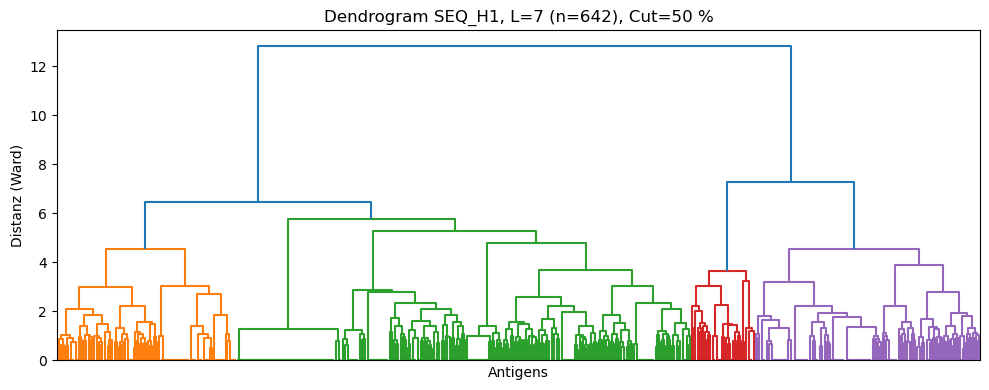


- SEQ_H1, Länge=8: 11 Sequenzen
   MaxDist=3.903, Cut@50% = 1.951


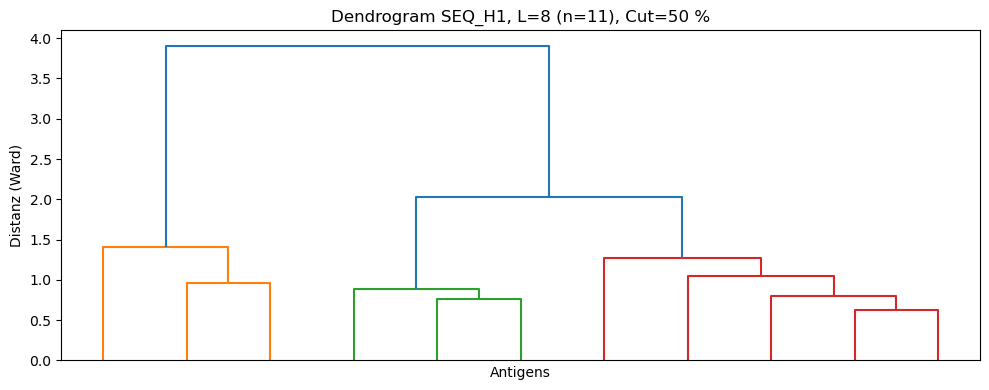


- SEQ_H1, Länge=9: 59 Sequenzen
   MaxDist=5.489, Cut@50% = 2.745


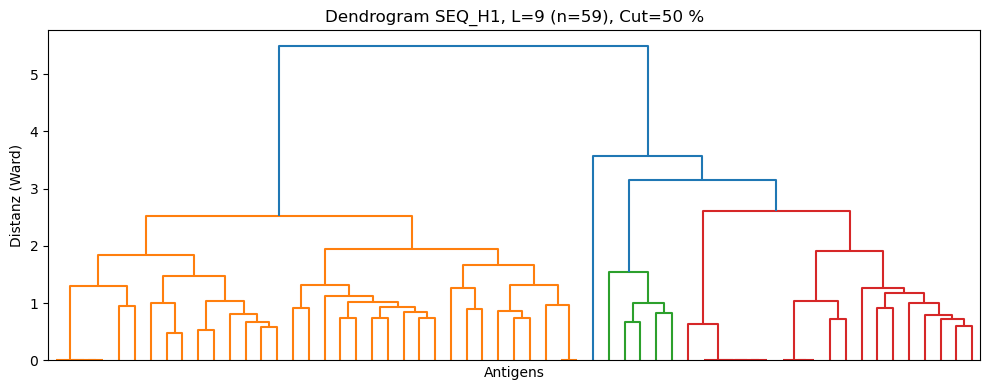


- SEQ_H2, Länge=5: 210 Sequenzen
   MaxDist=5.696, Cut@50% = 2.848


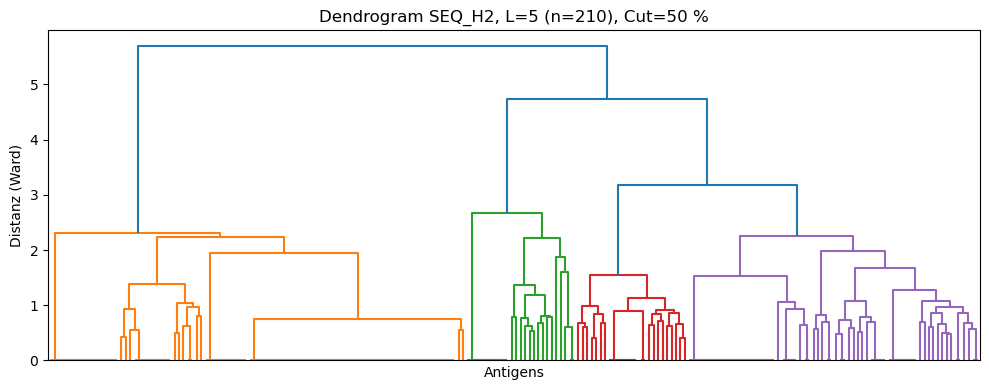


- SEQ_H2, Länge=6: 488 Sequenzen
   MaxDist=10.288, Cut@50% = 5.144


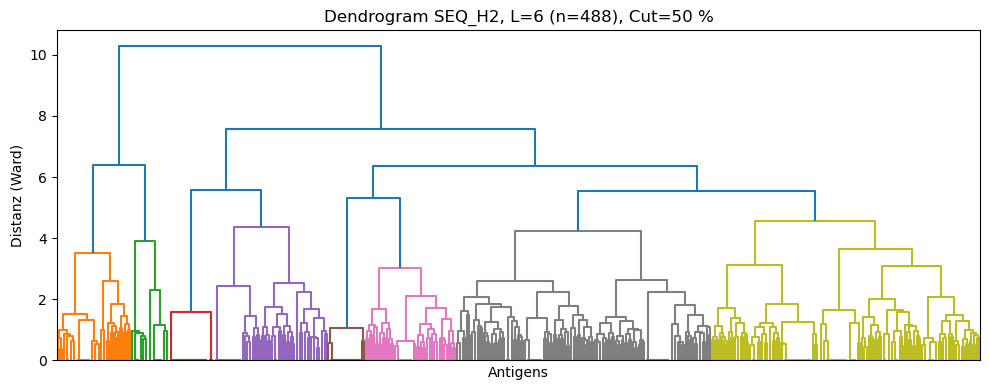


- SEQ_H2, Länge=8: 14 Sequenzen
   MaxDist=1.890, Cut@50% = 0.945


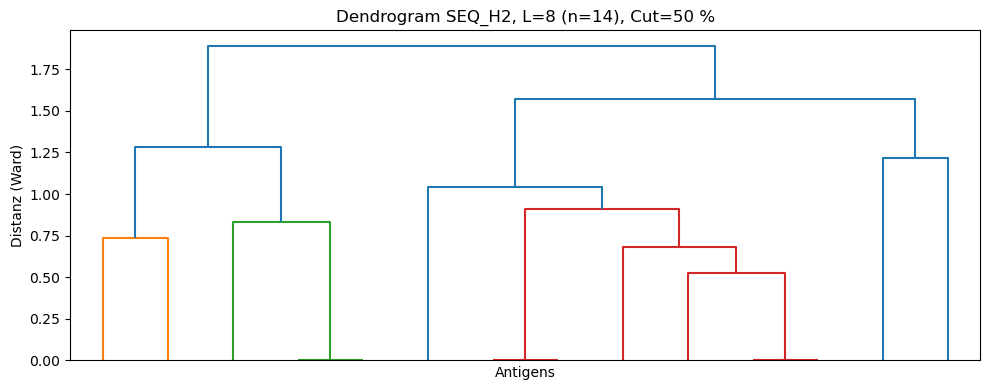


- SEQ_L1, Länge=10: 2 Sequenzen
   MaxDist=1.491, Cut@50% = 0.746


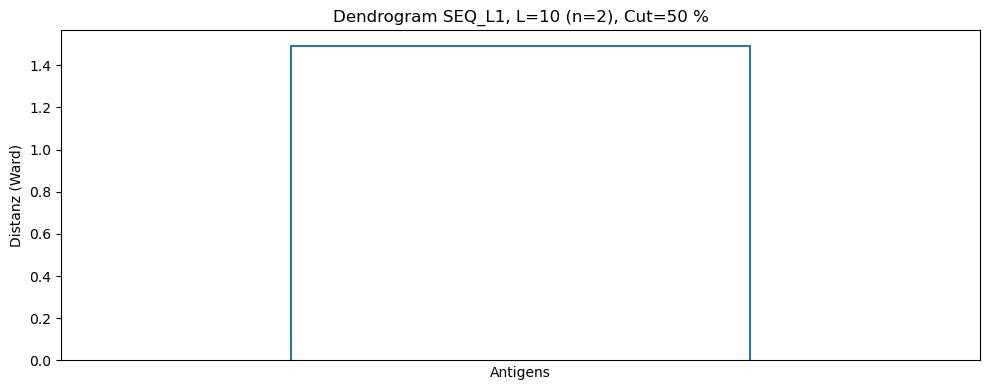


- SEQ_L1, Länge=11: 387 Sequenzen
   MaxDist=11.942, Cut@50% = 5.971


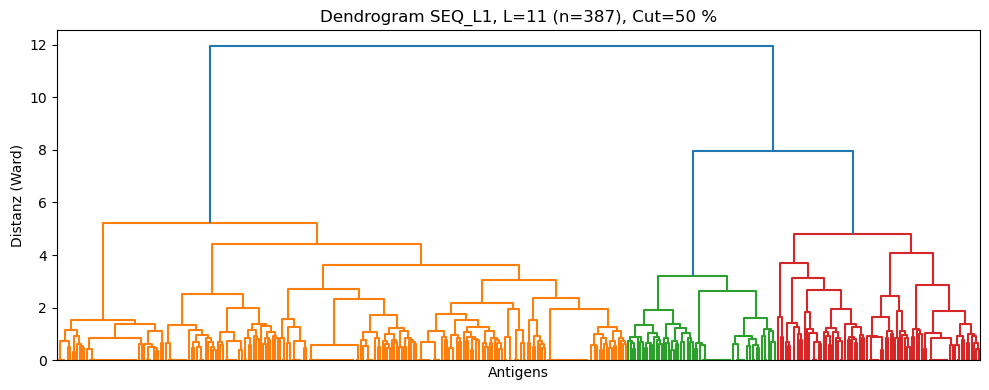


- SEQ_L1, Länge=12: 98 Sequenzen
   MaxDist=3.830, Cut@50% = 1.915


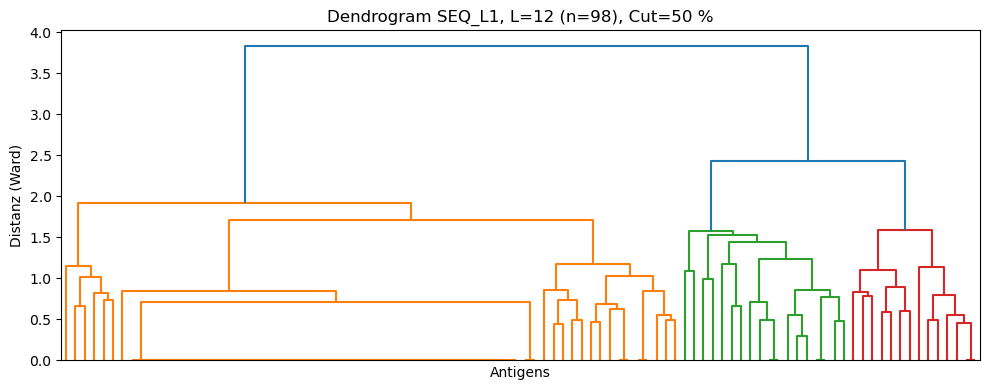


- SEQ_L1, Länge=13: 59 Sequenzen
   MaxDist=6.262, Cut@50% = 3.131


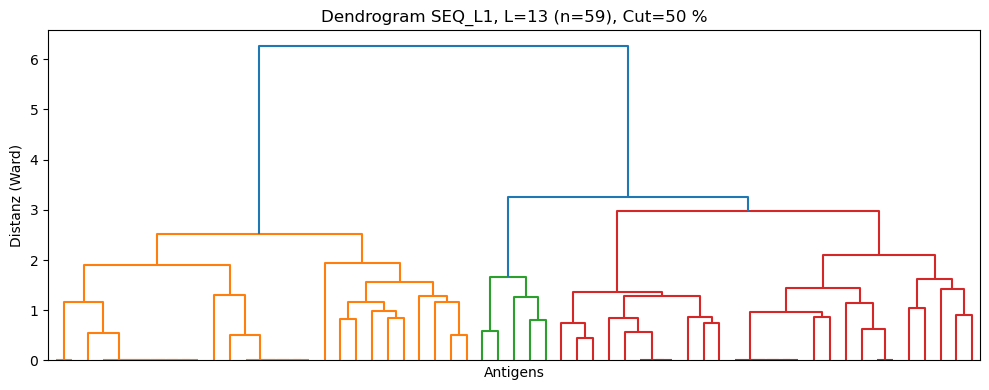


- SEQ_L1, Länge=14: 101 Sequenzen
   MaxDist=4.842, Cut@50% = 2.421


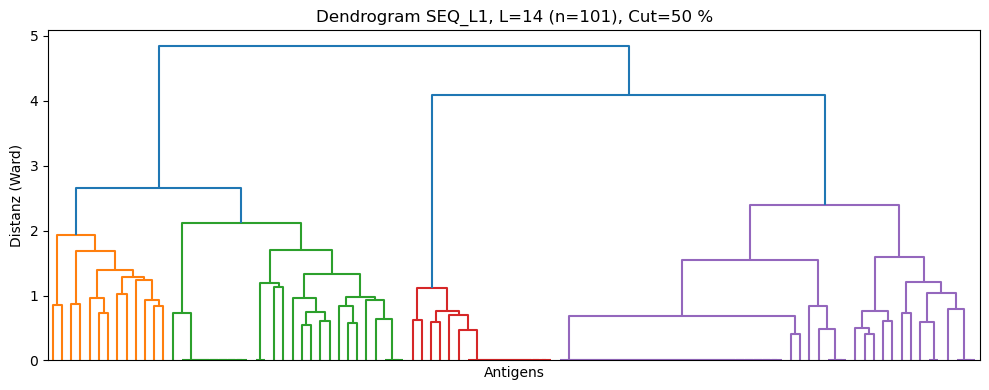


- SEQ_L1, Länge=15: 5 Sequenzen
   MaxDist=1.433, Cut@50% = 0.717


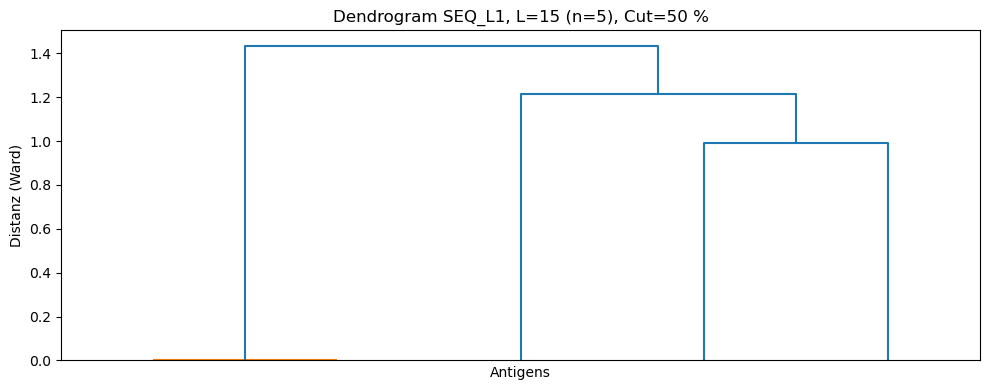


- SEQ_L1, Länge=16: 35 Sequenzen
   MaxDist=2.614, Cut@50% = 1.307


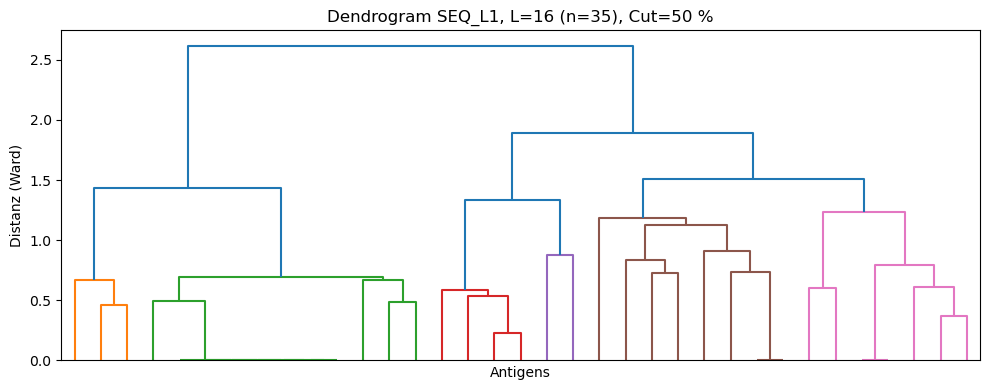


- SEQ_L1, Länge=17: 25 Sequenzen
   MaxDist=2.314, Cut@50% = 1.157


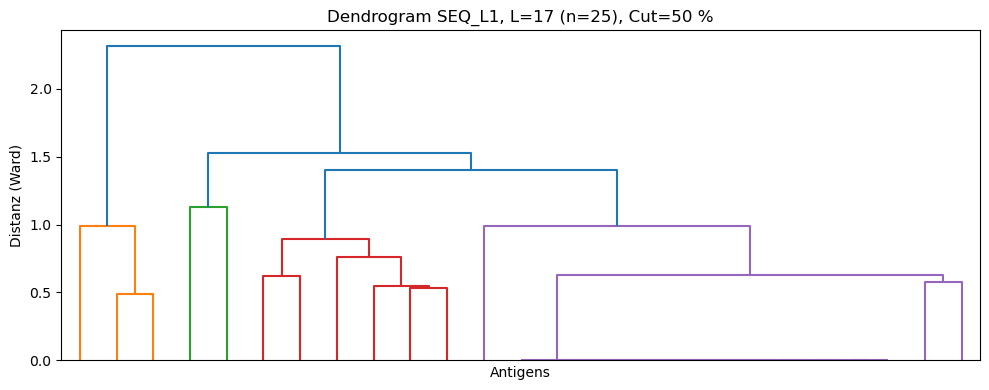


- SEQ_L2, Länge=7: 712 Sequenzen
   MaxDist=12.782, Cut@50% = 6.391


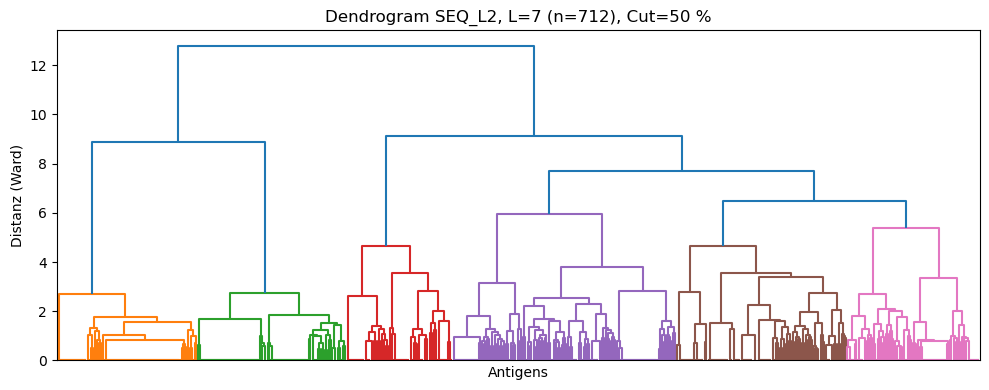


- SEQ_L3, Länge=5: 9 Sequenzen
   MaxDist=2.405, Cut@50% = 1.202


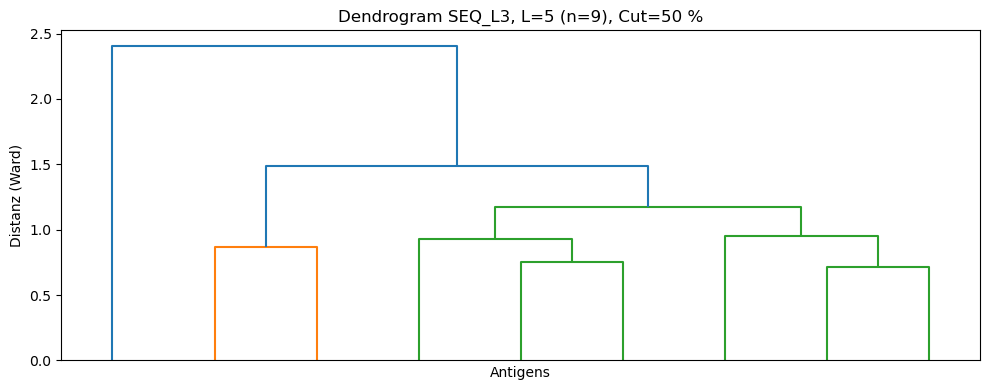


- SEQ_L3, Länge=8: 47 Sequenzen
   MaxDist=4.389, Cut@50% = 2.195


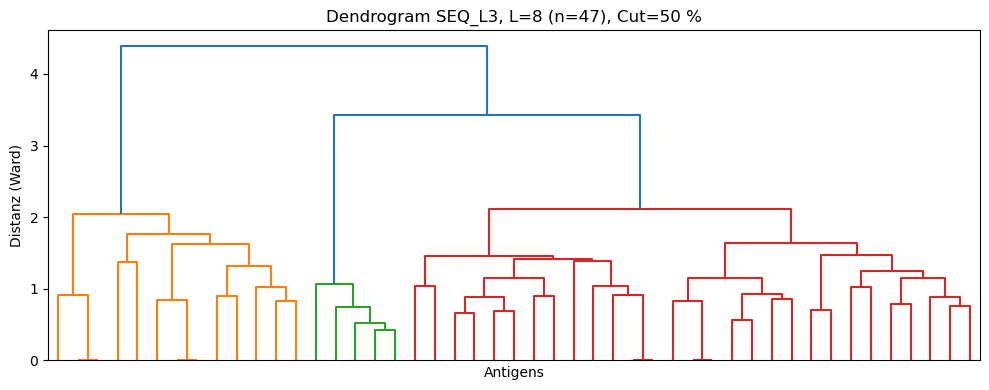


- SEQ_L3, Länge=9: 390 Sequenzen
   MaxDist=21.161, Cut@50% = 10.580


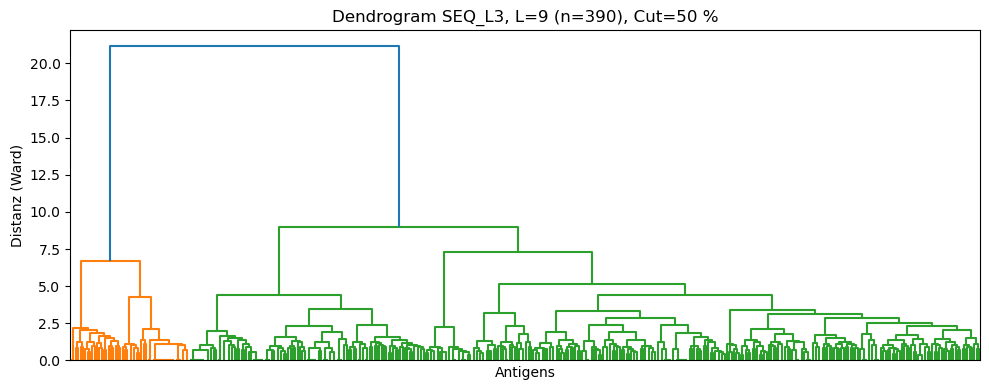


- SEQ_L3, Länge=10: 161 Sequenzen
   MaxDist=8.704, Cut@50% = 4.352


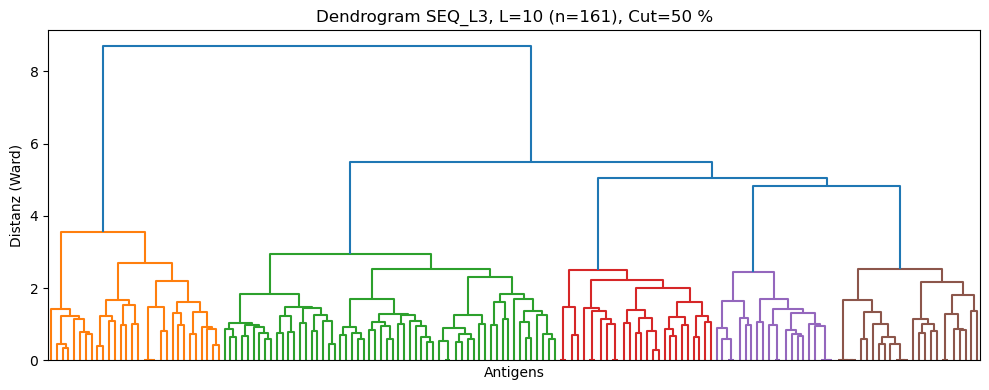


- SEQ_L3, Länge=11: 105 Sequenzen
   MaxDist=5.478, Cut@50% = 2.739


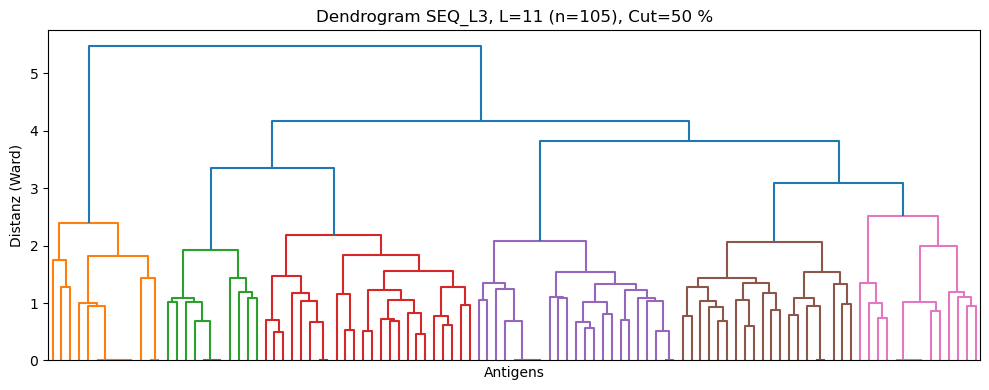

In [69]:
#Hierarchical Clustering nach sortieren nach Sequenzlängen
#Jeder DataFrame enthält Spalten: ['pdb', 'Hchain', 'Lchain', 'sequence', 'embedding_dimension N']

# 50 % der maximalen merge-distanz als cut
threshold_ratio = 0.5

# CDR-Regionen (gleich den Keys in feature_spaces)
outdir = "data/cdr_cluster_ESMC_by_length_tsvs"
os.makedirs(outdir, exist_ok=True) # sicherstellen, dass der ordner existiert

for region in seq_regions:
    fs = feature_spaces.get(region) # hole dataframe mit embeddings und weiteren infos für diese region
    if fs is None or fs.empty:
        continue # wenn kein dataframe gefunden oder leer, nächste region

    # berechne sequenz-längen
    fs["length"] = [len(i) for i in fs[region]]
    lengths = sorted(fs["length"].unique())

    for L in lengths:
        # subset nur dieser länge
        sub = fs[fs["length"] == L].reset_index(drop=True)
        n = len(sub)
        print(f"\n- {region}, Länge={L}: {n} Sequenzen")

        if n < 2:
            continue # wenn weniger als 2 einträge überspringen, weil kein clustering möglich ist

        # embedding-spalten sammeln
        emb_cols = [c for c in sub.columns if c.startswith("emb_") or c.startswith("embedding_dimension")]
        if not emb_cols:
            continue # falls keine embedding-spalten vorhanden sind, überspringen

        # feature-matrix und labels
        X = sub[emb_cols].values
        labels = (
            sub["pdb"].astype(str)
            + "_" + sub["Hchain"].fillna("")
            + "_" + sub["Lchain"].fillna("")
        ).tolist()

        # clustering per ward-linkage (hierarchisches clustering)
        Z = linkage(X, method="ward", metric="euclidean") # erstellen dendrogram baum
        max_dist = Z[-1,2] #größte distanz im letzten merge-schritt
        cut = threshold_ratio * max_dist # schwelle berechnen für cutoff
        print(f"   MaxDist={max_dist:.3f}, Cut@{int(threshold_ratio*100)}% = {cut:.3f}")

        # cluster-labels ermitteln
        sub["cluster"] = fcluster(Z, t=cut, criterion="distance") # array von cluster-ids

        # alles als tsv speichern, inklusive aller spalten + cluster
        out_path = os.path.join(outdir, f"clusters_{region}_len{L}.tsv")
        with open(out_path, "w", newline="") as f:
            writer = csv.writer(f, delimiter="\t")
            writer.writerow(list(sub.columns)) # header
            writer.writerows(sub.values)       # alle zeilen

        # dendrogram plotten und anzeigen
        plt.figure(figsize=(10,4))
        dendrogram(
            Z,
            labels=labels,
            leaf_rotation=90,
            leaf_font_size=6,
            color_threshold=cut # farbig markieren, wo der cut liegt
        )
        plt.xticks([]); plt.xlabel("Antigens")
        plt.ylabel("Distanz (Ward)")
        plt.title(f"Dendrogram {region}, L={L} (n={n}), Cut={int(threshold_ratio*100)} %")
        plt.tight_layout()
        plt.show()



3

 -> SEQ_H1, Länge=7: 642 Sequenzen


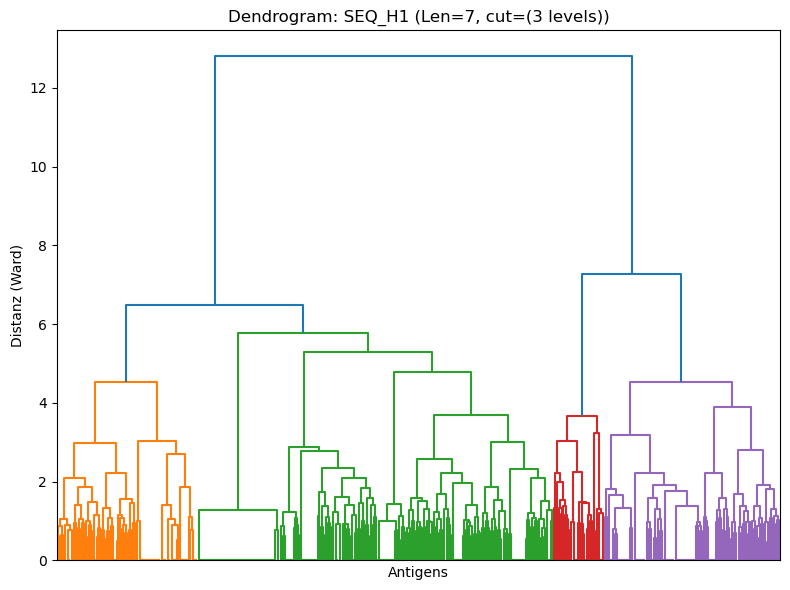

1

 -> SEQ_H1, Länge=8: 11 Sequenzen


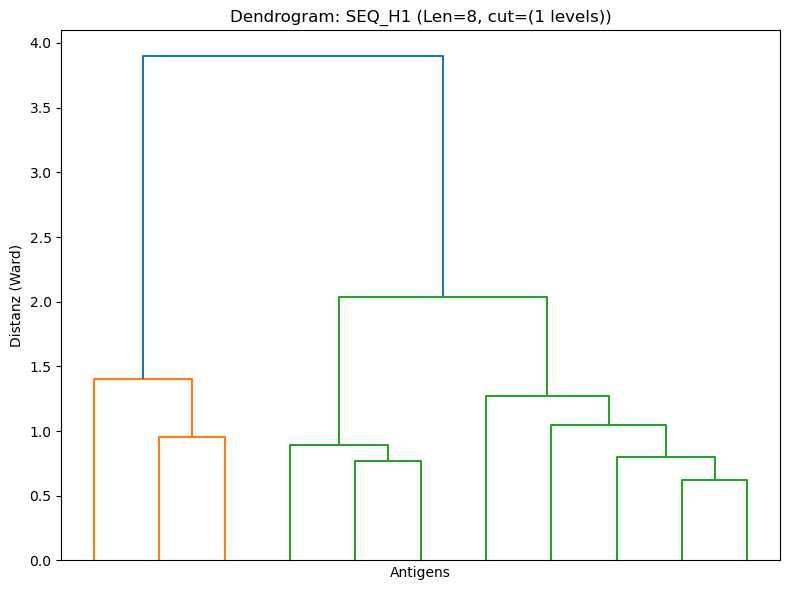

0

 -> SEQ_H1, Länge=9: 59 Sequenzen


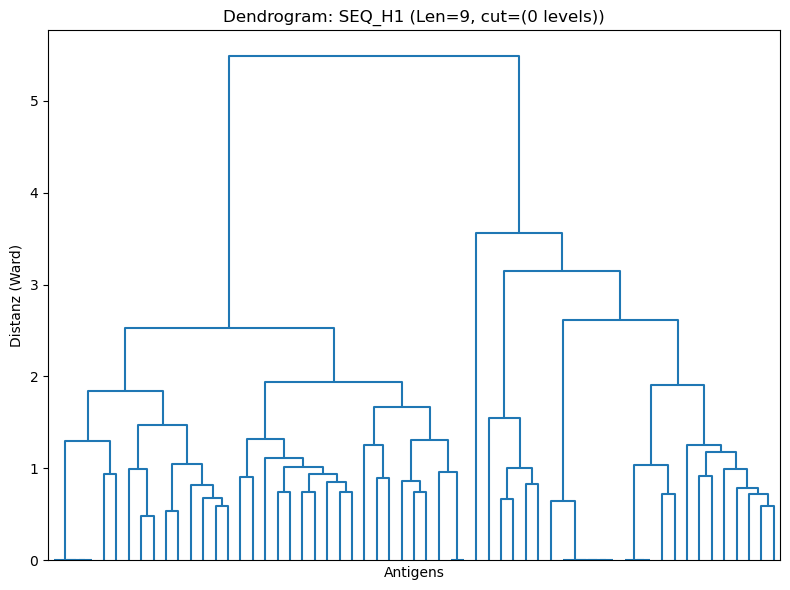

0

 -> SEQ_H2, Länge=5: 210 Sequenzen


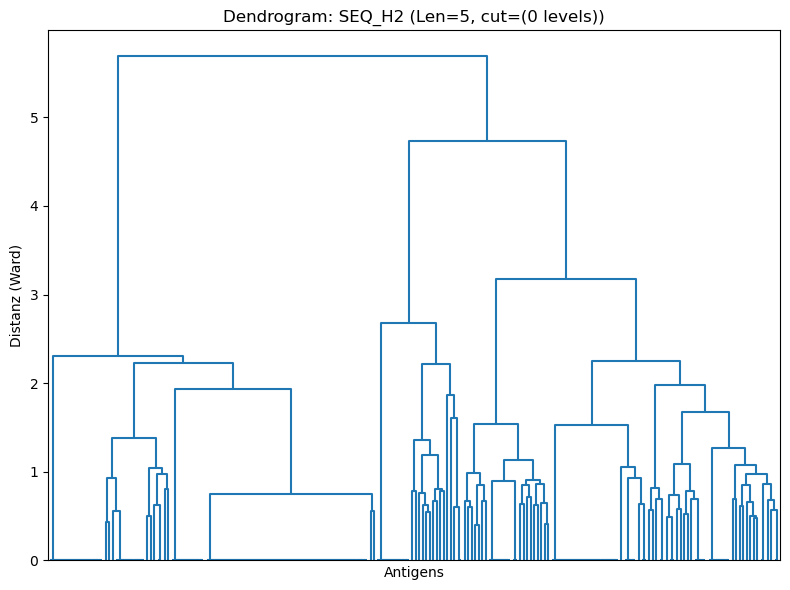

7

 -> SEQ_H2, Länge=6: 488 Sequenzen


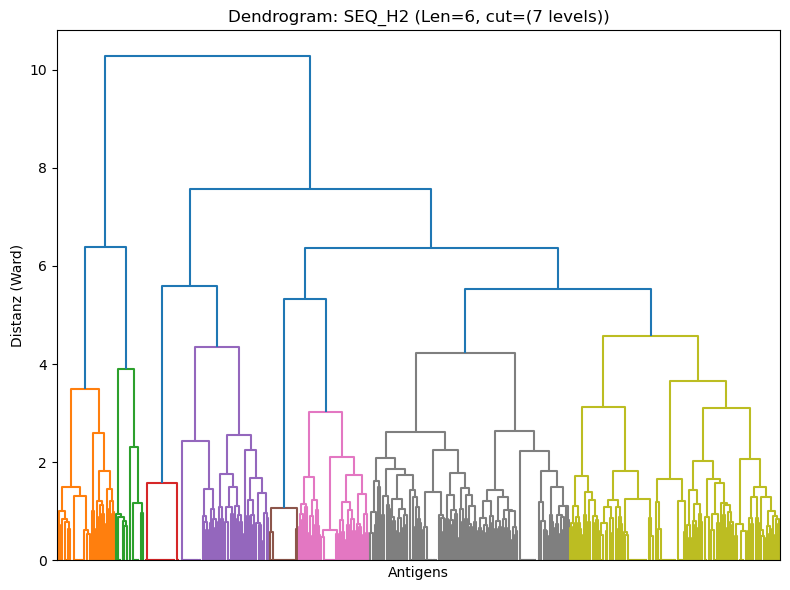

0

 -> SEQ_H2, Länge=8: 14 Sequenzen


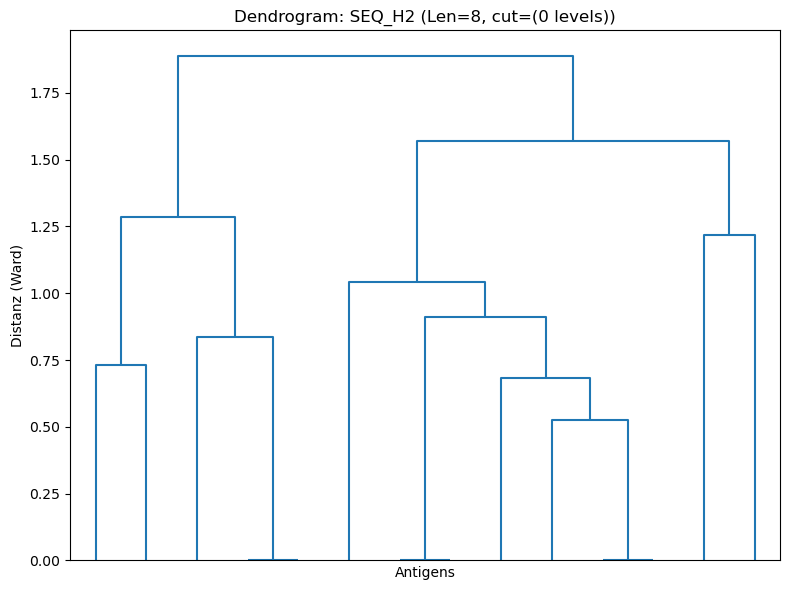

0

 -> SEQ_L1, Länge=10: 2 Sequenzen


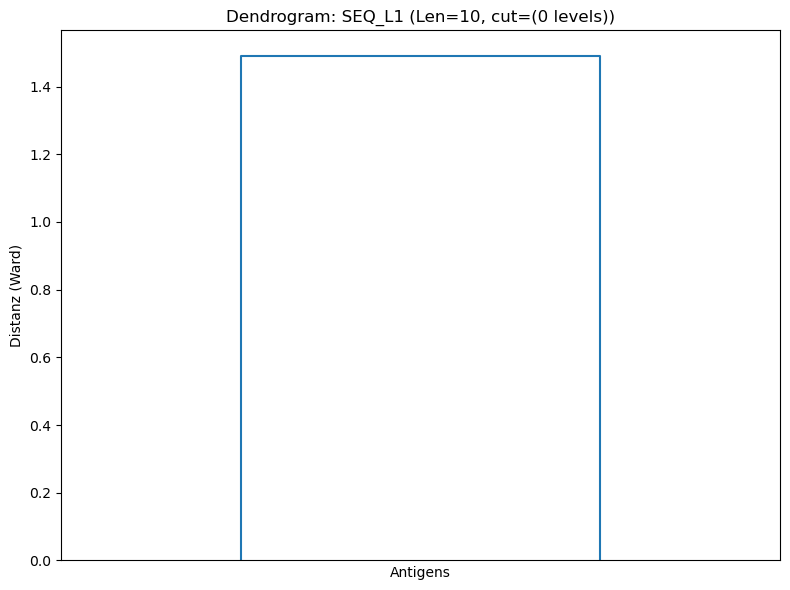

0

 -> SEQ_L1, Länge=11: 387 Sequenzen


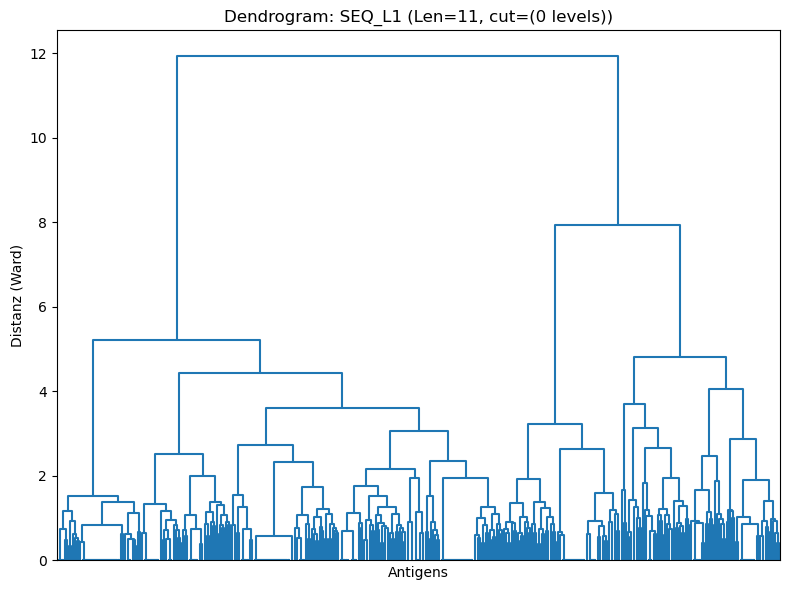

1

 -> SEQ_L1, Länge=12: 98 Sequenzen


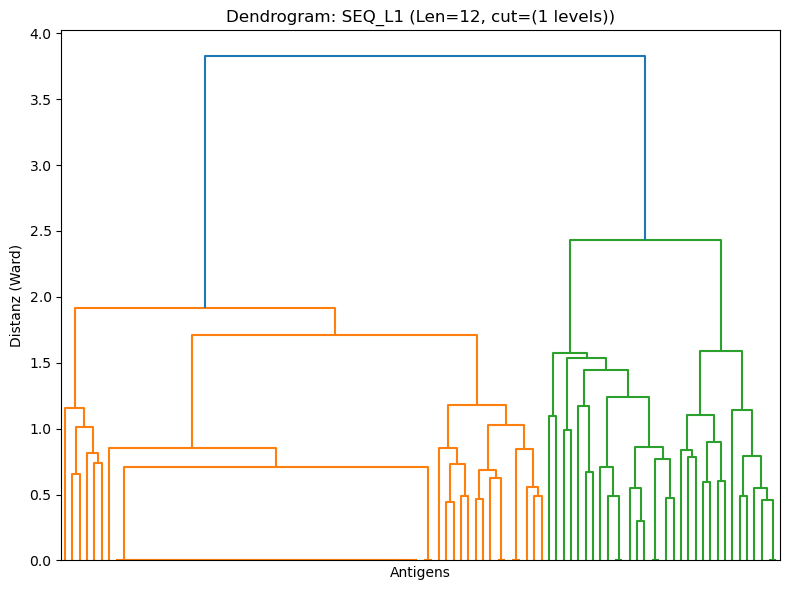

0

 -> SEQ_L1, Länge=13: 59 Sequenzen


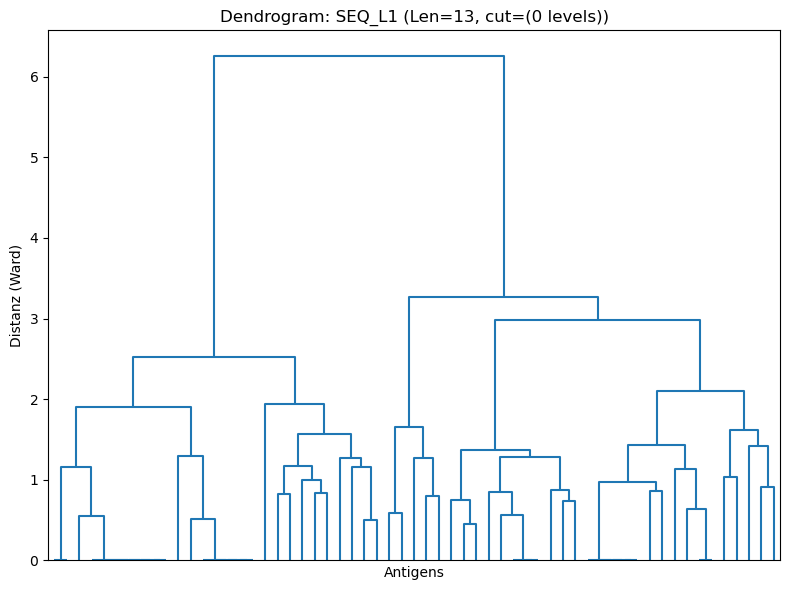

0

 -> SEQ_L1, Länge=14: 101 Sequenzen


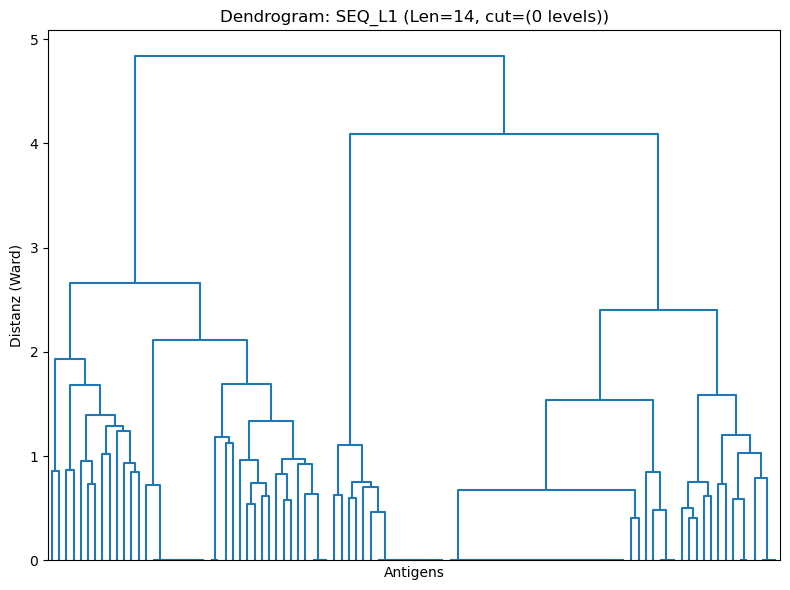

0

 -> SEQ_L1, Länge=15: 5 Sequenzen


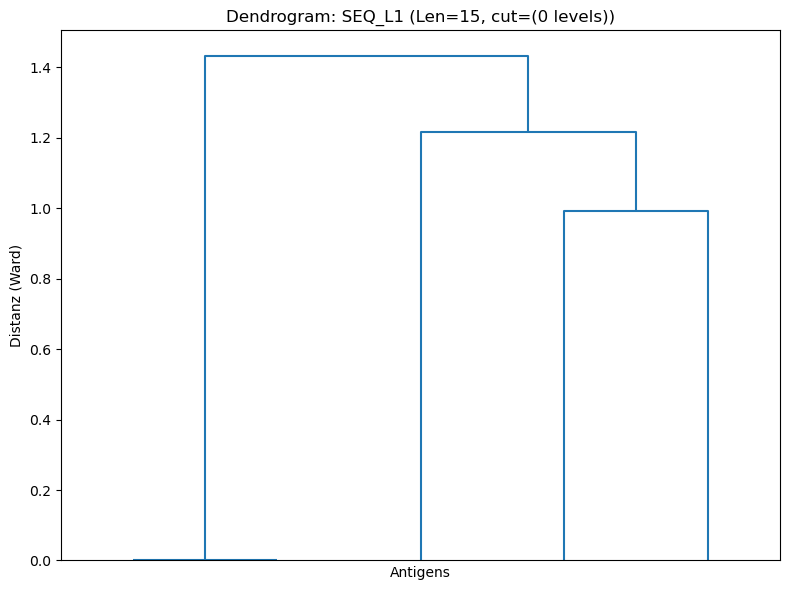

0

 -> SEQ_L1, Länge=16: 35 Sequenzen


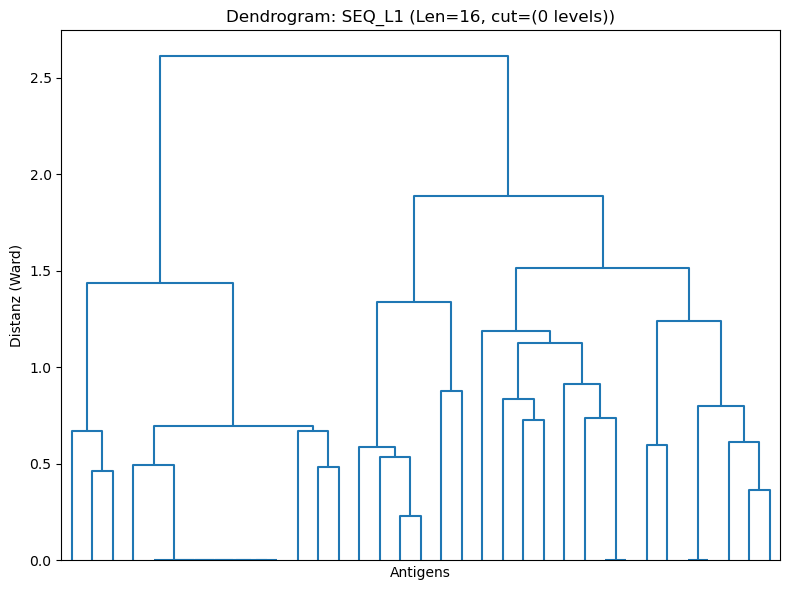

0

 -> SEQ_L1, Länge=17: 25 Sequenzen


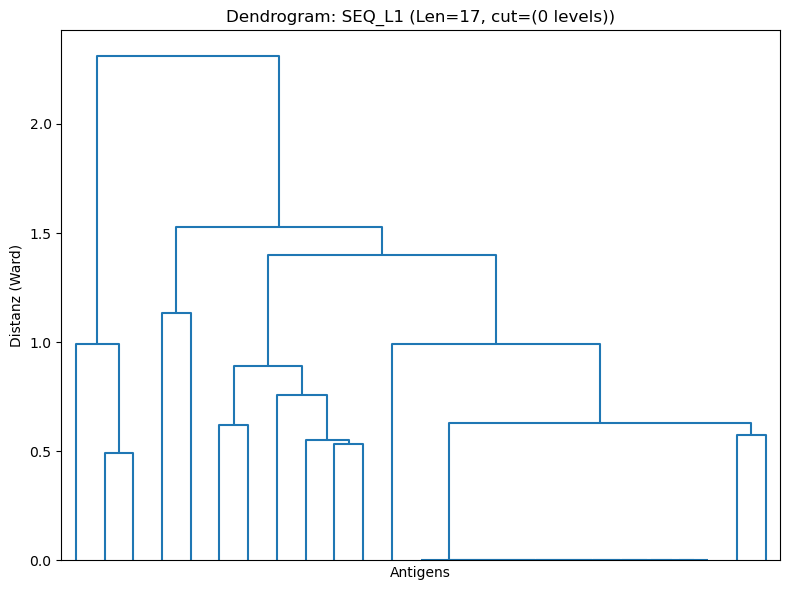

0

 -> SEQ_L2, Länge=7: 712 Sequenzen


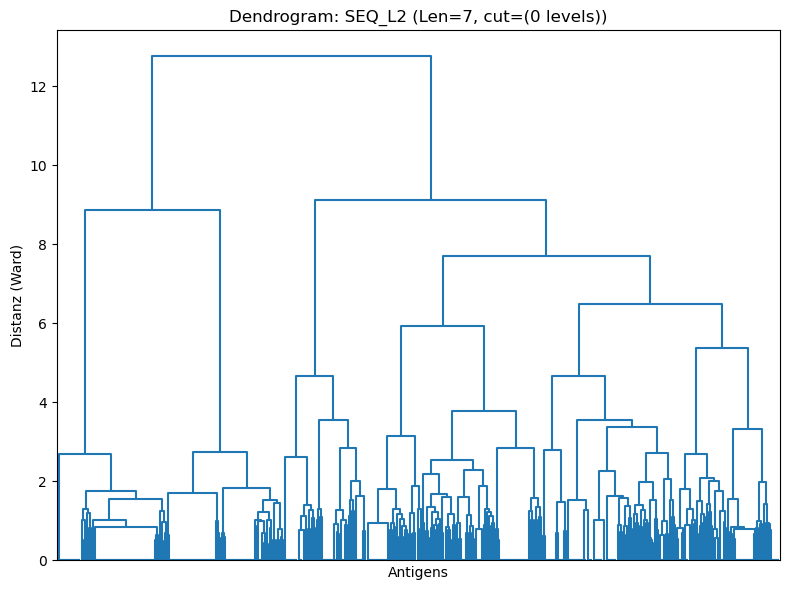

0

 -> SEQ_L3, Länge=5: 9 Sequenzen


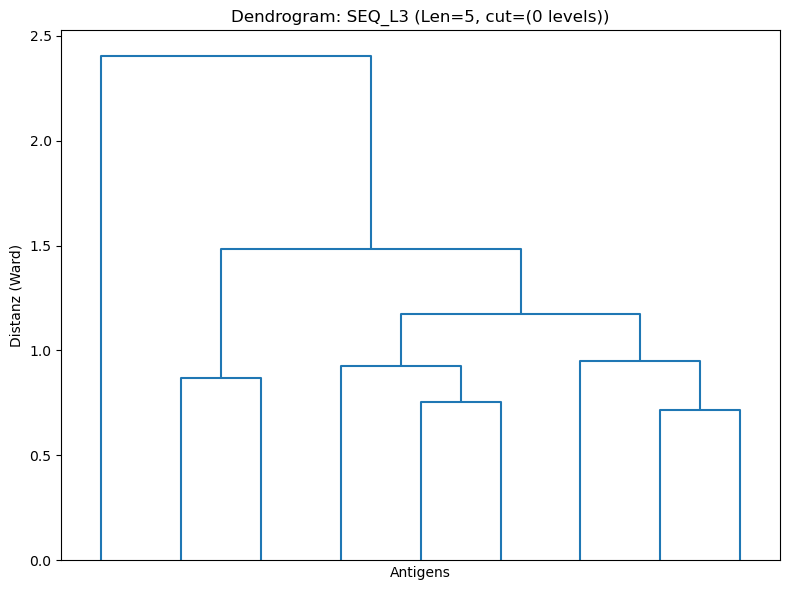

0

 -> SEQ_L3, Länge=8: 47 Sequenzen


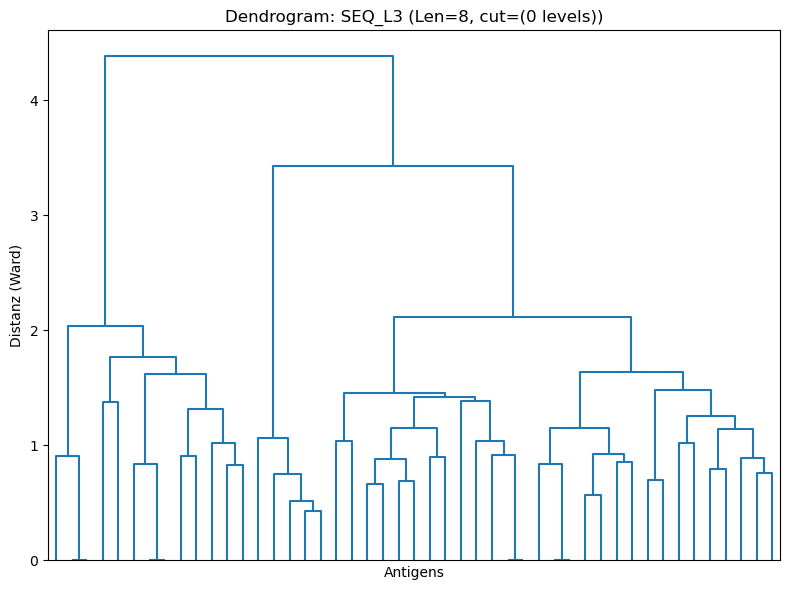

0

 -> SEQ_L3, Länge=9: 390 Sequenzen


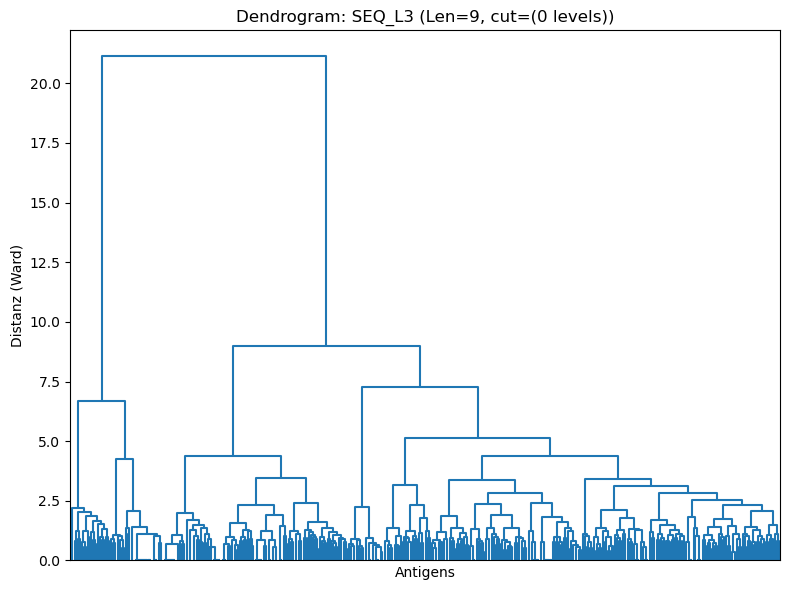

1

 -> SEQ_L3, Länge=10: 161 Sequenzen


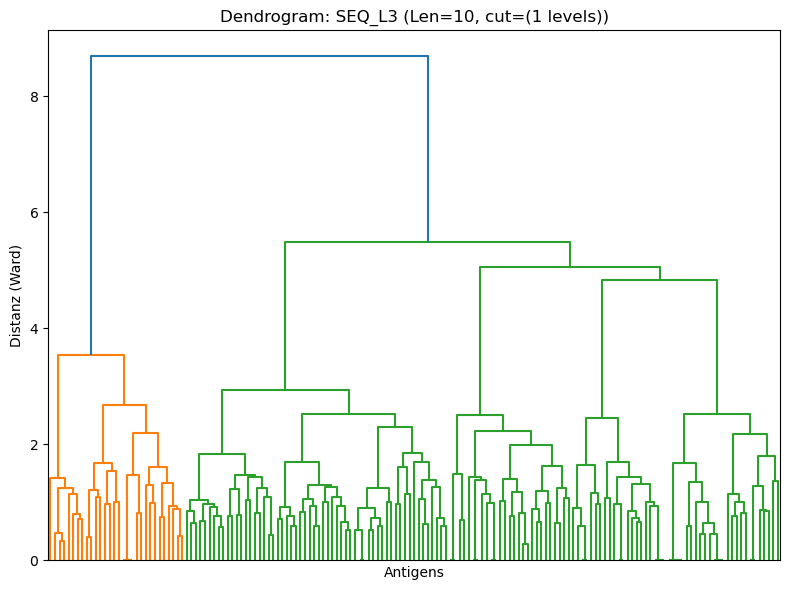

0

 -> SEQ_L3, Länge=11: 105 Sequenzen


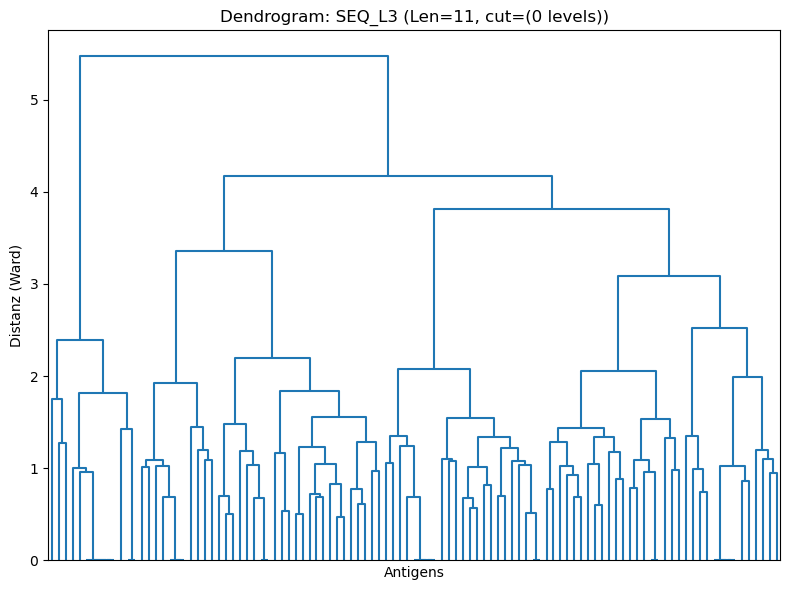

In [70]:
# Hierarchisch Clustering nach sortieren nach Sequenzlängen mit vorbestimmter anzahl an Clustern basierend auf den referenzclustern
# CDR-Regionen (gleich den Keys in feature_spaces)

# Ausgabe-Ordner anlegen
outdir = "data/cdr_Cluster_ESMC_by_length_pre_defined_tsvs"
os.makedirs(outdir, exist_ok=True)  # falls der Ordner noch nicht existiert, anlegen

# Mapping aus (Region, Länge) -> gewünschte Anzahl Cluster (als Referenz aus bestehenden Clustern)
cluster_counts = {
    ("SEQ_H1", 7): 4, ("SEQ_H1", 8): 2, ("SEQ_H1", 9): 1,
    ("SEQ_H2", 5): 1, ("SEQ_H2", 6): 8, ("SEQ_H2", 8): 1,
    ("SEQ_L1",11): 1, ("SEQ_L1",12): 2,
    ("SEQ_L3",14): 3, ("SEQ_L3",15): 1,
    ("SEQ_L1",16): 1, ("SEQ_L1",17): 1,
    ("SEQ_L2", 7): 1,
    ("SEQ_L3", 8): 1, ("SEQ_L3", 9): 1,
    ("SEQ_L3",10): 2, ("SEQ_L3",11): 1,
}

for region in seq_regions:
    fs = feature_spaces.get(region)  # hole DataFrame für diese Region
    if fs is None or fs.empty:
        continue  # überspringen falls nicht vorhanden oder leer

    # berechne sequenz-längen
    fs["length"] = [len(i) for i in fs[region]]
    lengths = sorted(fs["length"].unique())  # finde alle unterschiedlichen Längen

    for L in lengths:
        # Parameter für Dendrogramm-Cut: berechne wie viele Ebenen wir heruntergehen müssen, um auf Anzahl Cluster zu kommen
        levels_down = cluster_counts.get((region, L), 1) - 1  # Anzahl der Ebenen für den Cut; etwa 2 = 3 Teilbäume
        print(levels_down)

        sub = fs[fs["length"] == L].reset_index(drop=True)  # nur Sequenzen mit dieser Länge
        n = len(sub)
        print(f"\n -> {region}, Länge={L}: {n} Sequenzen")

        if n < 2:
            continue  # wenn weniger als 2 Einträge, kein Clustering möglich

        # 1) Embedding-Spalten sammeln
        emb_cols = [c for c in sub.columns if c.startswith("emb_") or c.startswith("embedding_dimension")]
        if not emb_cols:
            continue  # falls keine Embedding-Spalten vorhanden, überspringen

        # 2) Feature-Matrix und Labels
        X = sub[emb_cols].values

        # Hierarchisches Clustering
        Z = linkage(X, method="ward", metric="euclidean")

        # Berechne Cutoff-Threshold für Farbtrennung
        threshold = Z[-levels_down, 2] if levels_down <= Z.shape[0] else 0.0

        # Dendrogramm nur zur Gewinnung der Farbgruppen
        ddata = dendrogram(
            Z,
            labels=[str(i) for i in range(len(sub[region].tolist()))],
            color_threshold=threshold,
            no_plot=True
        )

        # Blattfarben extrahieren und eindeutige Clusterfarben sammeln
        leaves = ddata["leaves"]
        leaf_colors = ddata["leaves_color_list"]
        leaf_color_map = dict(zip(leaves, leaf_colors))

        unique_colors = []
        for col in leaf_colors:
            if col not in unique_colors:
                unique_colors.append(col)

        # Mappe Farbe -> Cluster-ID
        color_cluster_map = {col: idx+1 for idx, col in enumerate(unique_colors)}

        # TSV-Einträge vorbereiten: (pdb_id, region, Länge, Cluster-ID)
        entries = []
        for col in unique_colors:
            cid = color_cluster_map[col]
            leaves_in_cluster = [leaf for leaf, c in leaf_color_map.items() if c == col]
            for leaf_idx in leaves_in_cluster:
                pdb_id = sub.loc[leaf_idx]["pdb"]
                entries.append((pdb_id, region, L, cid))

        # Schreibe TSV-Datei für diese Region und Länge
        out_path = os.path.join(outdir, f"clusters_{region}_len{L}_pre_decided.tsv")
        with open(out_path, "w", newline="") as f:
            writer = csv.writer(f, delimiter="\t")
            writer.writerow(list(sub.columns))  # Header
            writer.writerows(sub.values)        # alle Zellen

        # Plot des Dendrogramms mit Farb-Cut
        plt.figure(figsize=(8, 6))
        dendrogram(
            Z,
            labels=[str(i) for i in range(len(sub[region].tolist()))],
            color_threshold=threshold,
            leaf_rotation=0,
            leaf_font_size=6
        )
        plt.title(f"Dendrogram: {region} (Len={L}, cut=({levels_down} levels))")
        plt.xticks([]); plt.xlabel("Antigens")
        plt.ylabel("Distanz (Ward)")
        plt.tight_layout()
        plt.show()


       

In [71]:
print(fs.columns)

Index(['pdb', 'Hchain', 'Lchain', 'model', 'antigen_name', 'antigen_species',
       'SEQ_L3', 'embedding_dimension 0', 'embedding_dimension 1',
       'embedding_dimension 2',
       ...
       'embedding_dimension 1144', 'embedding_dimension 1145',
       'embedding_dimension 1146', 'embedding_dimension 1147',
       'embedding_dimension 1148', 'embedding_dimension 1149',
       'embedding_dimension 1150', 'embedding_dimension 1151', 'cluster',
       'length'],
      dtype='object', length=1161)


KeyError: 'CDR_H1'

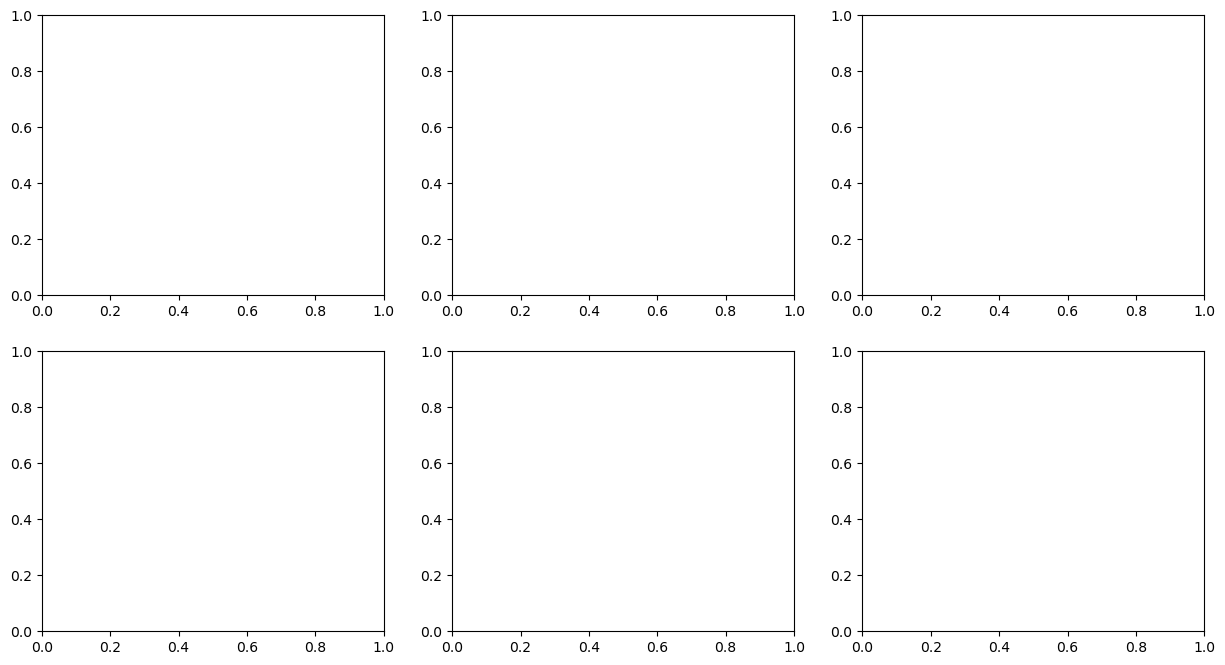

In [72]:
import data_cleanup.functions
data_cleanup.functions.show_PCA(feature_spaces, 3)